### Create half-gaussian meridional wind pulse 

* Spatially uniform wind stress applied in the meridional direction of the domain bahia_01_noShelf (240x180 grid points).
* Generate meridional binary file for windstress.
* Gaussian pulse, e-fold of value `sigma`, max windstress of `max_tau`, centered in time around `center`
* In namelist `data`, variable `ExternalForcingCycle` should match `end_time*3600` (`end_time` in seconds) and `ExternalForcingPeriod` should be equal to `(end_time*3600)/nt`.
* If you are using this forcing file, your run should not exceed `end_time` hoursin simulation time because the forcing will start again after that time (E.g. if end_time is 10 hrs, a new wind event will start again after 10 hours). If you wish to run for longer, restart from pickup files and comment out the external frocing options in `data`.

In [1]:
20*3600/60

1200.0

In [1]:
import matplotlib.pyplot as plt
import numpy as np

### INPUT

Only change these values

In [ ]:
## Gaussian pulse
nt = 180 # number of wind records
end_time = 60 # end time of records (hrs) - Should be the same as ExternalForcingCycle (in seconds) in data namelist
t = np.linspace(0, end_time, nt) # time array of wind records
max_tau =  0.1 # original 0.1
sigma = 1
center = 2.5 # base 3.5 hr, faster 2.5 hr, slower 4.5
gauss = max_tau * np.exp(-((t-center)**2)/(2*sigma))
mask = t > center
gauss[mask] = 0

## Grid size
nx = 336 # domain bahia01_expand: 272
ny = 352 # domain bahia01_expand: 320  

# filename
run_desc = 'halfgauss2p5hr' # descriptive string to add to wind filename. 
                            # Final name is eg. zonal_halfgauss2p5hr_240x180.bin 

### Make wind stress array

This is your half gaussian pulse
0.004393693362340742


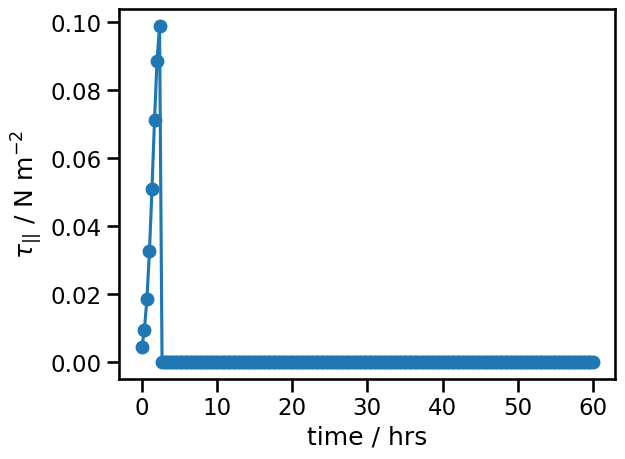

In [17]:
### Plot gaussian
plt.plot(t,gauss,'-o')
plt.xlabel('time / hrs')
plt.ylabel(r'$\tau_{||}$ / N m$^{-2}$')
file_path = "/Users/estebancruz/MITgcm/verification/BayIW/input/tau_simulation.png"
plt.savefig(file_path, dpi=300)
print('This is your half gaussian pulse')
print(gauss[0])

In [18]:
windstress= np.expand_dims(np.expand_dims(gauss,0),0) + np.zeros((nx,ny,nt))
alpha = np.radians(90) # Meridional winds directed to the north need 90deg rotation
#zonal_tau = windstress*np.cos(alpha)
merid_tau = windstress*np.sin(alpha)

In [19]:
### Write binary files
dt = np.dtype('>f8')  # float 64 big endian

wind_fname1 = 'merid_%s_%dx%d.bin' %(run_desc,nx,ny)
fileobj = open(wind_fname1, mode='wb')
dd=merid_tau.transpose((2,1,0))
dd.astype(dt).tofile(fileobj,"")
fileobj.close()

(15667200,)


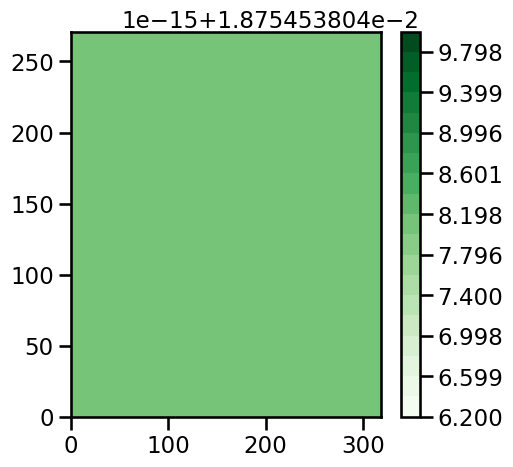

In [20]:
# Check that bin file works when read by MITgcm

cc=np.fromfile(wind_fname1, dtype=dt)
print(np.shape(cc))

bF=np.reshape(cc,[nx,ny,nt],'F') # F to read in Fortran order

fig,ax = plt.subplots(1,1, figsize=(5,5))

pc = ax.contourf(bF[:,:,2], 20, cmap='Greens')
plt.colorbar(pc,ax=ax)

(0.0, 60.0)

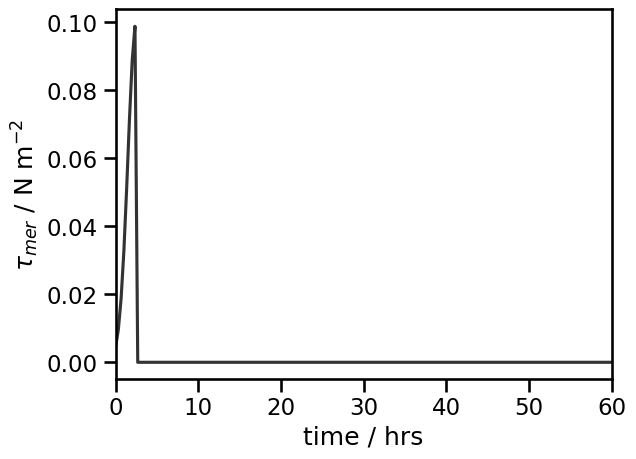

In [21]:
# Make a plot for talks
import seaborn as sns

sns.set_context('talk')
plt.plot(t, gauss, '-', color='0.2')
plt.xlabel('time / hrs')
plt.ylabel(r'$\tau_{mer}$ / N m$^{-2}$')
plt.xlim(0,end_time)

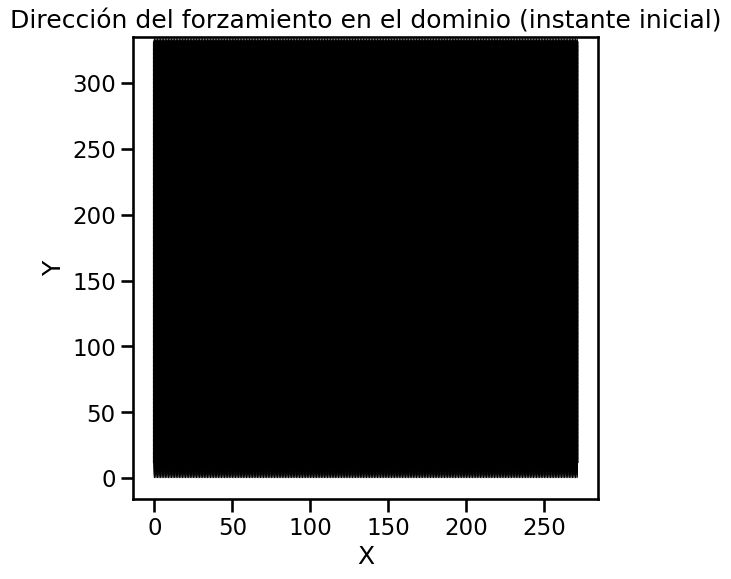

In [22]:
# Supongamos que tienes zonal_tau y merid_tau
X, Y = np.meshgrid(np.arange(nx), np.arange(ny))
U = np.zeros_like(windstress[:,:,0])  # zonal_tau debería ser cero
V = merid_tau[:,:,0]  # Primer instante de tiempo

plt.figure(figsize=(6,6))
plt.quiver(X, Y, U, V, scale=0.1)
plt.title("Dirección del forzamiento en el dominio (instante inicial)")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


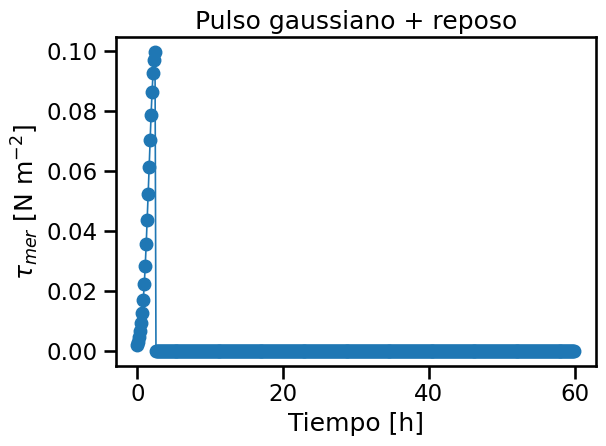


Archivo creado: ./merid_halfgauss2p5hr_272x320.bin
Nº de registros: 448  (dt ≃ 0.41 h)


In [15]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Genera un archivo binario de esfuerzo del viento (meridional) para MITgcm.
— Pulso gaussiano media-onda de duración «pulse_hours» (por defecto 24 h).
— Se puede añadir un tramo de reposo «rest_hours» (τ = 0) tras el pulso.
— Resolución temporal uniforme: dt = pulse_hours / (nt-1).
— Salida: archivo big-endian float64, orden Fortran (k,j,i).
"""

import os
import numpy as np
import matplotlib.pyplot as plt


# ---------- 1. Rutinas auxiliares ------------------------------------------------
def _half_gaussian(t, max_tau, sigma, center):
    """Media gaussiana que se anula después del centro."""
    tau = max_tau * np.exp(-((t - center) ** 2) / (2 * sigma ** 2))
    tau[t > center] = 0       # apaga después del máximo
    return tau


def _windstress_field(nx, ny, tau_t, angle_deg=90):
    """Crea el cubo 3-D (i,j,k) de τ_mer con la orientación deseada."""
    base = np.expand_dims(np.expand_dims(tau_t, 0), 0)          # (1,1,nt)
    field = base + np.zeros((nx, ny, len(tau_t)))               # (nx,ny,nt)
    alpha = np.radians(angle_deg)
    return field * np.sin(alpha)                                # solo meridional


def _write_binary(field, fname, dtype='>f8'):
    """Escribe el array en formato binario big-endian float64."""
    with open(fname, 'wb') as f:
        field.transpose((2, 1, 0)).astype(dtype).tofile(f, "")


# ---------- 2. Función de alto nivel ---------------------------------------------
def create_wind_forcing(
        pulse_hours=24,        # duración del pulso
        rest_hours=0,          # horas extra de reposo (τ = 0)
        nt=60,                 # registros dentro del pulso
        max_tau=0.1, sigma=1, center=2.5,
        nx=272, ny=320,
        run_desc="halfgauss",
        outdir="."):

    """Crea archivo binario «merid_<run_desc>_<nx>x<ny>.bin» y devuelve su path."""

    # 2.1 Tiempo y pulso gaussiano
    dt = pulse_hours / (nt - 1)                 # resolución horaria
    t_pulse = np.linspace(0, pulse_hours, nt)   # eje temporal del pulso
    tau_pulse = _half_gaussian(t_pulse, max_tau, sigma, center)

    # 2.2 Bloque de reposo opcional
    if rest_hours > 0:
        n_rest = int(np.round(rest_hours / dt))
        tau_rest = np.zeros(n_rest)
        tau_total = np.concatenate((tau_pulse, tau_rest))
    else:
        tau_total = tau_pulse

    # 2.3 Cubo (x,y,t), escritura y gráficas rápidas
    field = _windstress_field(nx, ny, tau_total, angle_deg=90)
    fname = os.path.join(outdir, f"merid_{run_desc}_{nx}x{ny}.bin")
    _write_binary(field, fname)

    # 2.4 Gráfica de control
    plt.figure()
    plt.plot(np.arange(len(tau_total)) * dt, tau_total, '-o', lw=1.2)
    plt.xlabel('Tiempo [h]'); plt.ylabel(r'$\tau_{mer}$ [N m$^{-2}$]')
    plt.title('Pulso gaussiano + reposo'); plt.tight_layout()
    plt.show()

    # 2.5 Devuelve nombre y serie para inspección
    return fname, tau_total


# ---------- 3. Ejemplo de uso -----------------------------------------------------
if __name__ == "__main__":
    # Pulso estándar de 24 h seguido de 12 h de reposo
    fname, tau = create_wind_forcing(
        pulse_hours=24,
        rest_hours=36,
        nt=180,
        max_tau=0.1,
        sigma=0.9,
        center=2.5,
        nx=272, ny=320,
        run_desc="halfgauss2p5hr",
        outdir="."
    )
    print(f"\nArchivo creado: {fname}")
    print(f"Nº de registros: {len(tau)}  (dt ≃ {24/59:.2f} h)")
